# Dataset visualization

This notebook generates the requested plots from the **full dataset** (including hidden columns).

- By default it generates the dataset in-memory using `enterprise_risk_generator`.
- Optionally, set `CSV_PATH` to load a previously generated full dataset CSV.

Each section contains **one plot per cell** for quick inspection.

In [1]:

# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from enterprise_risk_generator import GeneratorConstants, ClassProportions, generate_dataset

plt.rcParams["figure.figsize"] = (7.5, 5.0)
plt.rcParams["axes.grid"] = True


In [2]:

# Load or generate full dataset
CSV_PATH = None  # set to "full_dataset_with_hidden.csv" to load instead of generating
# CSV_PATH = "../risk_train_dataset.csv"

if CSV_PATH:
    df_all = pd.read_csv(CSV_PATH)
else:
    constants = GeneratorConstants()
    _, df_all = generate_dataset(N=20000,
                                 seed=42,
                                 outlier_prob=0.01,
                                 return_all_columns=True,
                                 constants=constants)

df_all.head()


,revenue,costs,audited,market_focus,ceo_tenure_years,risk,profit_margin,cost_risk_factor,sales_risk_factor
0,1.205171e+07,7.976931e+06,1.0,[Industrial],5.976938,healthy,0.338108,-2.196849,-0.217017
1,3.140887e+06,2.887137e+06,0.0,[Contract],6.034470,healthy,0.080789,1.828256,-0.278512
2,1.882039e+07,1.601990e+07,0.0,[Industrial],3.522911,healthy,0.148801,0.998530,0.114401
3,2.276113e+07,1.777111e+07,1.0,[Industrial],6.762237,healthy,0.219234,-0.130510,0.702341
4,1.262955e+06,9.673602e+05,0.0,"[Contract, Industrial]",3.758875,sales_risk,0.234050,-0.582250,2.674772


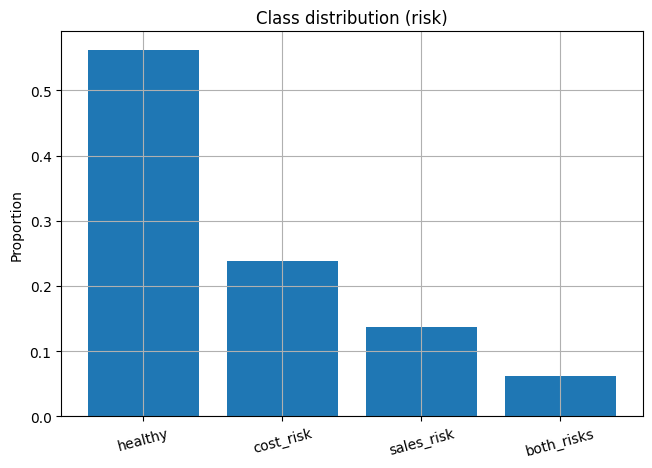

In [3]:

# Basic dataset checks (class distribution)
dist = df_all["risk"].value_counts(normalize=True)
plt.figure()
plt.bar(dist.index, dist.values)
plt.title("Class distribution (risk)")
plt.ylabel("Proportion")
plt.xticks(rotation=15)
plt.show()


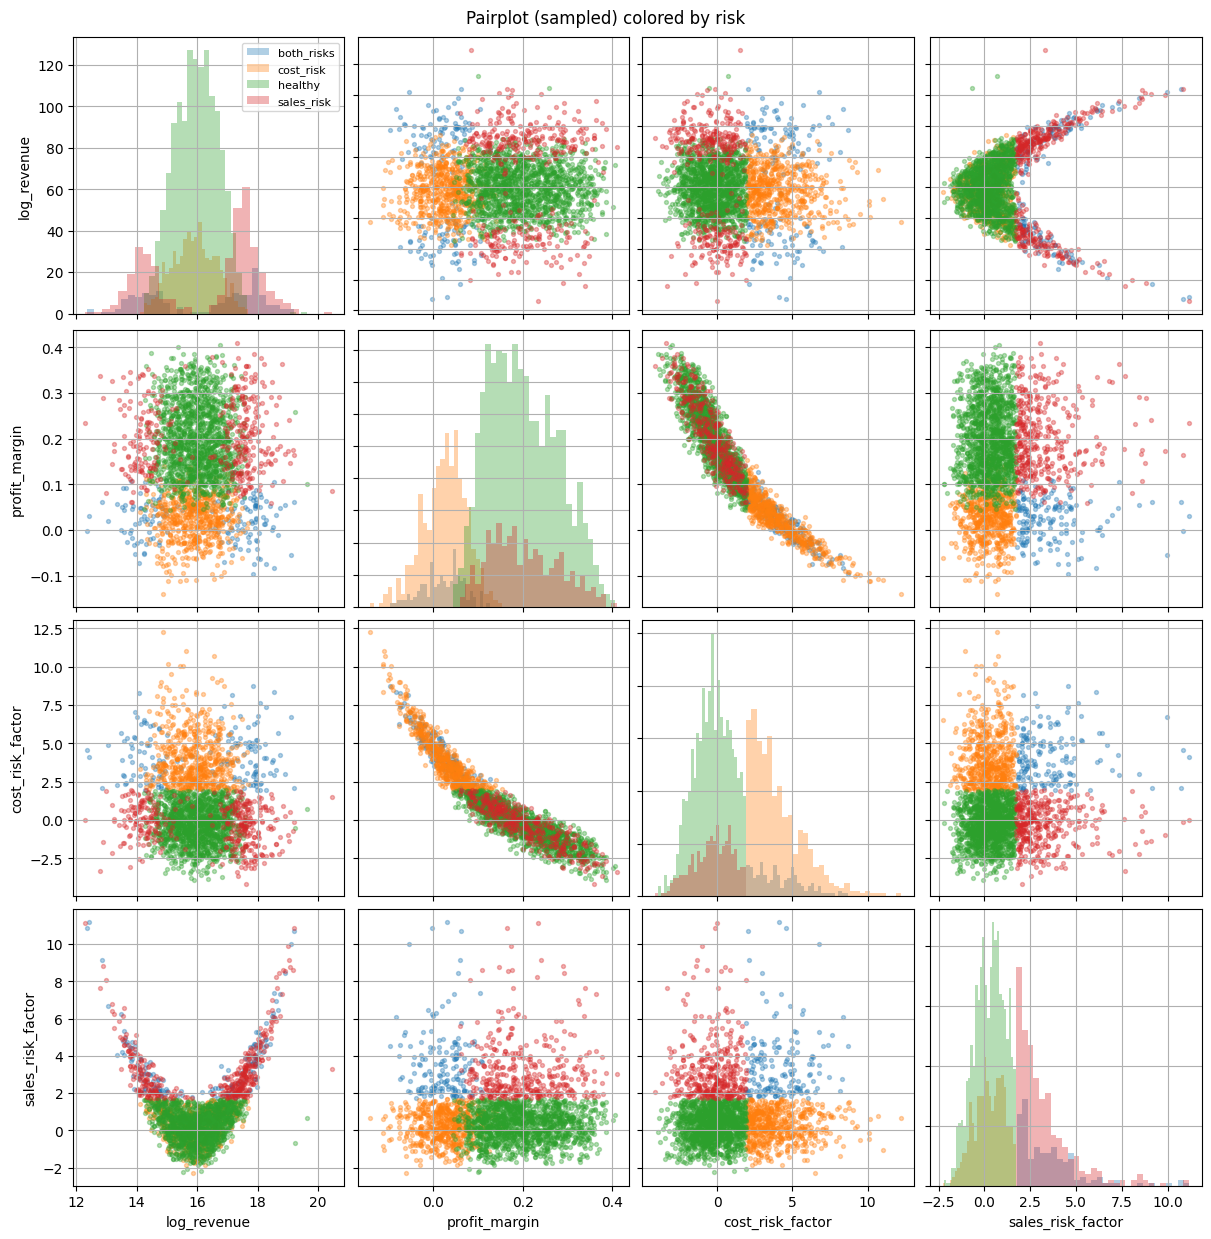

In [4]:

# Pairplot (custom) with hue = risk
# Uses: log_revenue, profit_margin, cost_risk_factor, sales_risk_factor
d = df_all.copy()

d["log_revenue"] = np.log(pd.to_numeric(d["revenue"], errors="coerce").clip(lower=1.0))
cols = ["log_revenue", "profit_margin", "cost_risk_factor", "sales_risk_factor"]
d = d[cols + ["risk"]].dropna()

# sample for speed
if len(d) > 2500:
    d = d.sample(2500, random_state=0)

classes = sorted(d["risk"].unique().tolist())
k = len(cols)

fig, axes = plt.subplots(k, k, figsize=(3.0*k, 3.0*k), constrained_layout=True)

for i in range(k):
    for j in range(k):
        ax = axes[i, j]
        if i == j:
            for cls in classes:
                v = pd.to_numeric(d.loc[d["risk"] == cls, cols[i]], errors="coerce").dropna().to_numpy()
                ax.hist(v, bins=30, alpha=0.35, label=cls)
            if j == 0:
                ax.legend(fontsize=8)
        else:
            for cls in classes:
                sub = d[d["risk"] == cls]
                ax.scatter(pd.to_numeric(sub[cols[j]], errors="coerce"),
                           pd.to_numeric(sub[cols[i]], errors="coerce"),
                           s=8, alpha=0.35)
        if i == k - 1:
            ax.set_xlabel(cols[j])
        else:
            ax.set_xlabel("")
            ax.set_xticklabels([])
        if j == 0:
            ax.set_ylabel(cols[i])
        else:
            ax.set_ylabel("")
            ax.set_yticklabels([])

fig.suptitle("Pairplot (sampled) colored by risk", y=1.02)
plt.show()


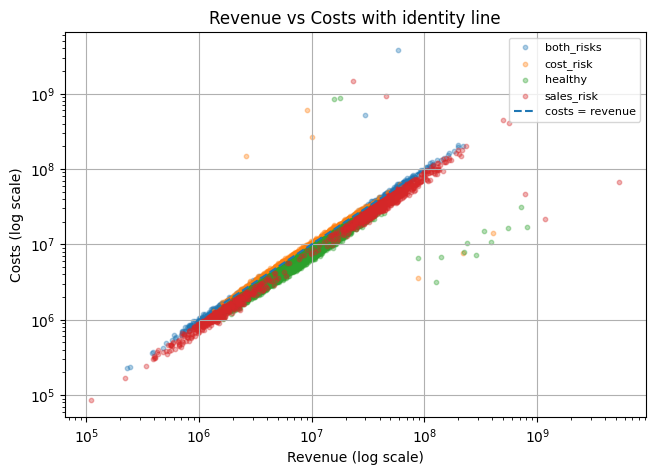

In [5]:

# Revenue vs costs (log-log) + identity line
d = df_all[["revenue", "costs", "risk"]].copy()
d["revenue"] = pd.to_numeric(d["revenue"], errors="coerce")
d["costs"] = pd.to_numeric(d["costs"], errors="coerce")
d = d.dropna()

if len(d) > 8000:
    d = d.sample(8000, random_state=0)

classes = sorted(d["risk"].unique().tolist())
plt.figure()

for cls in classes:
    sub = d[d["risk"] == cls]
    plt.scatter(sub["revenue"], sub["costs"], s=10, alpha=0.35, label=cls)

xy = np.concatenate([d["revenue"].to_numpy(), d["costs"].to_numpy()])
lo, hi = np.nanpercentile(xy, 1), np.nanpercentile(xy, 99)
plt.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1.5, label="costs = revenue")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Revenue (log scale)")
plt.ylabel("Costs (log scale)")
plt.title("Revenue vs Costs with identity line")
plt.legend(fontsize=8)
plt.show()


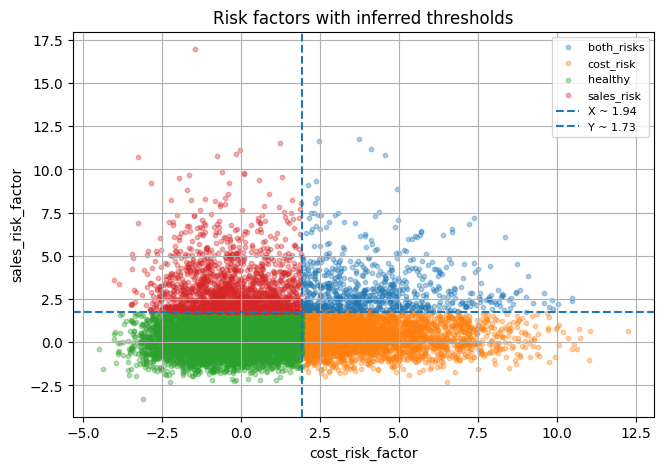

In [6]:

# Cost risk vs Sales risk with thresholds (estimated from labels)
d = df_all[["cost_risk_factor", "sales_risk_factor", "risk"]].copy()
d["cost_risk_factor"] = pd.to_numeric(d["cost_risk_factor"], errors="coerce")
d["sales_risk_factor"] = pd.to_numeric(d["sales_risk_factor"], errors="coerce")
d = d.dropna()

if len(d) > 12000:
    d = d.sample(12000, random_state=0)

cost_pos = d["risk"].isin(["cost_risk", "both_risks"])
sales_pos = d["risk"].isin(["sales_risk", "both_risks"])

def estimate_threshold(factor, pos_mask):
    v = factor.to_numpy()
    pos = pos_mask.to_numpy().astype(bool)
    v_pos = v[pos & ~np.isnan(v)]
    v_neg = v[(~pos) & ~np.isnan(v)]
    if len(v_pos) == 0 or len(v_neg) == 0:
        return np.nan
    return 0.5 * (np.min(v_pos) + np.max(v_neg))

X_hat = estimate_threshold(d["cost_risk_factor"], cost_pos)
Y_hat = estimate_threshold(d["sales_risk_factor"], sales_pos)

classes = sorted(d["risk"].unique().tolist())
plt.figure()
for cls in classes:
    sub = d[d["risk"] == cls]
    plt.scatter(sub["cost_risk_factor"], sub["sales_risk_factor"], s=10, alpha=0.35, label=cls)

if not np.isnan(X_hat):
    plt.axvline(X_hat, linestyle="--", linewidth=1.5, label=f"X ~ {X_hat:.2f}")
if not np.isnan(Y_hat):
    plt.axhline(Y_hat, linestyle="--", linewidth=1.5, label=f"Y ~ {Y_hat:.2f}")

plt.xlabel("cost_risk_factor")
plt.ylabel("sales_risk_factor")
plt.title("Risk factors with inferred thresholds")
plt.legend(fontsize=8)
plt.show()


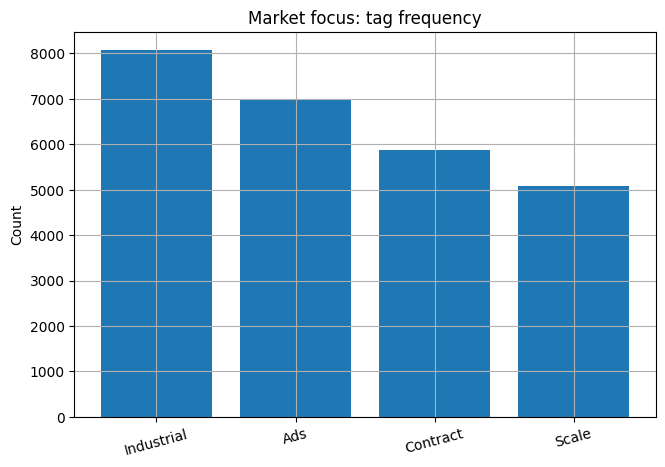

In [7]:

# Market focus histogram (tag frequency)
TAGS = ["Industrial", "Ads", "Contract", "Scale"]

def clean_market(x):
    if isinstance(x, list):
        return [str(t) for t in x]
    if isinstance(x, str):
        if x.startswith("[") and x.endswith("]"):
            inner = x.strip("[]").strip()
            if not inner:
                return []
            parts = [p.strip().strip("'").strip('"') for p in inner.split(",")]
            return [p for p in parts if p]
        return [x]
    return []

mf = df_all["market_focus"].apply(clean_market)

counts = {t: int(mf.apply(lambda lst: t in lst).sum()) for t in TAGS}
plt.figure()
plt.bar(list(counts.keys()), list(counts.values()))
plt.title("Market focus: tag frequency")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.show()


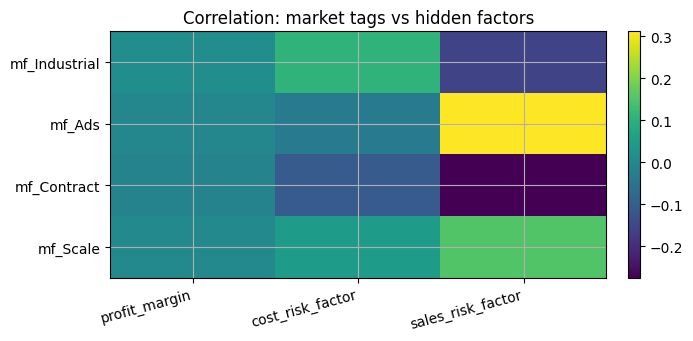

In [8]:

# Market focus correlations vs hidden factors (heatmap)
TAGS = ["Industrial", "Ads", "Contract", "Scale"]
mf = df_all["market_focus"].apply(lambda x: x if isinstance(x, list) else [])
mf_ind = pd.DataFrame({f"mf_{t}": mf.apply(lambda lst: int(t in lst)) for t in TAGS})

targets = ["profit_margin", "cost_risk_factor", "sales_risk_factor"]
corr_df = pd.concat([mf_ind.astype(float), df_all[targets].apply(pd.to_numeric, errors="coerce")], axis=1)
corr = corr_df.corr(numeric_only=True).loc[[f"mf_{t}" for t in TAGS], targets]

plt.figure(figsize=(7.0, 3.2))
im = plt.imshow(corr.to_numpy(), aspect="auto")
plt.xticks(range(len(targets)), targets, rotation=15, ha="right")
plt.yticks(range(len(TAGS)), [f"mf_{t}" for t in TAGS])
plt.title("Correlation: market tags vs hidden factors")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.show()


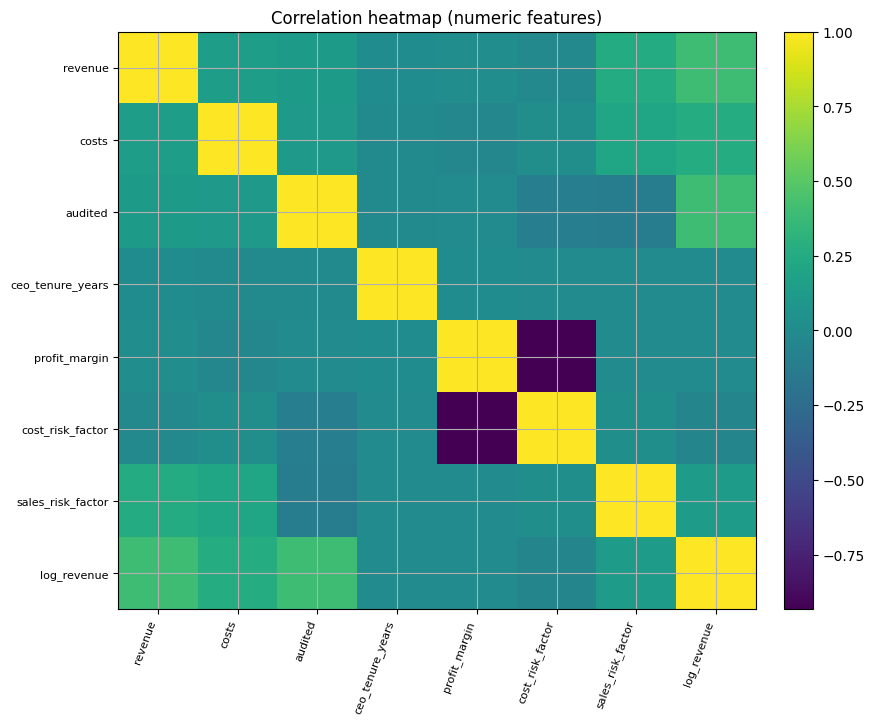

In [9]:

# Correlation heatmap between numeric features
num = df_all.drop(columns=["market_focus", "risk"]).apply(pd.to_numeric, errors="coerce")
num["log_revenue"] = np.log(num["revenue"].clip(lower=1.0))

corr = num.corr(numeric_only=True)

plt.figure(figsize=(9.0, 7.5))
im = plt.imshow(corr.to_numpy(), aspect="auto")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=70, ha="right", fontsize=8)
plt.yticks(range(len(corr.index)), corr.index, fontsize=8)
plt.title("Correlation heatmap (numeric features)")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.show()


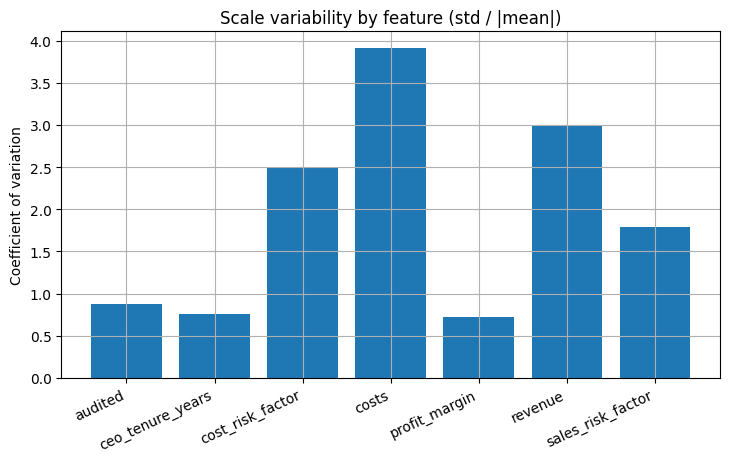

,mean,std,nan_rate
audited,5.636255e-01,4.960485e-01,0.00040
ceo_tenure_years,6.058398e+00,4.555277e+00,0.00030
cost_risk_factor,9.993895e-01,2.485517e+00,0.00000
costs,1.368434e+07,5.354848e+07,0.00040
profit_margin,1.496168e-01,1.075113e-01,0.00000
revenue,1.565328e+07,4.685803e+07,0.00045
sales_risk_factor,8.463757e-01,1.513013e+00,0.00000


In [10]:

# Summary statistics (mean and std) for numeric features
num = df_all.drop(columns=["market_focus", "risk"]).apply(pd.to_numeric, errors="coerce")
stats = pd.DataFrame({
    "mean": num.mean(numeric_only=True),
    "std": num.std(numeric_only=True),
    "nan_rate": num.isna().mean(),
}).sort_index()

# Plot: coefficient of variation (std/|mean|) to see scale differences
cv = (stats["std"] / stats["mean"].abs().replace(0, np.nan)).replace([np.inf, -np.inf], np.nan)

plt.figure(figsize=(8.5, 4.5))
plt.bar(cv.index, cv.values)
plt.title("Scale variability by feature (std / |mean|)")
plt.ylabel("Coefficient of variation")
plt.xticks(rotation=25, ha="right")
plt.show()

stats


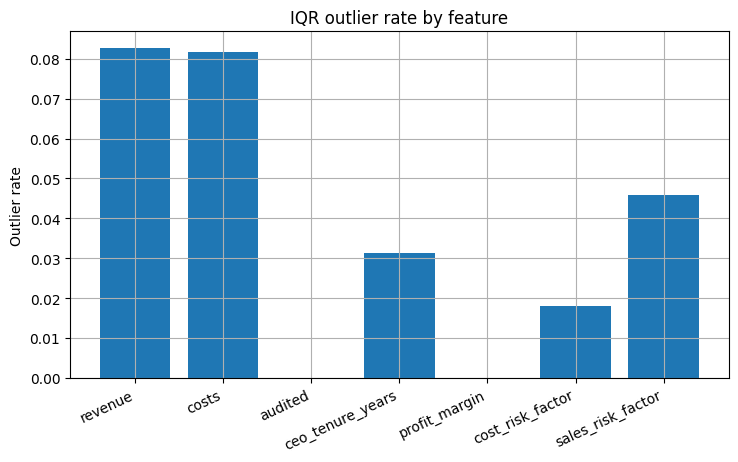

,outlier_rate_iqr,nan_rate,invalid_rate
feature,,,
revenue,0.082737,0.00045,NaN
costs,0.081633,0.00040,NaN
audited,0.000000,0.00040,0.00005
ceo_tenure_years,0.031209,0.00030,NaN
profit_margin,0.000000,0.00000,NaN
cost_risk_factor,0.017950,0.00000,NaN
sales_risk_factor,0.045950,0.00000,NaN


In [11]:

# Outlier measures per feature
def robust_outlier_rate(x: pd.Series):
    v = pd.to_numeric(x, errors="coerce").to_numpy()
    nan_rate = np.isnan(v).mean()
    v2 = v[~np.isnan(v)]
    if len(v2) < 10:
        return 0.0, float(nan_rate)
    q1, q3 = np.quantile(v2, [0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    out_rate = ((v2 < lo) | (v2 > hi)).mean()
    return float(out_rate), float(nan_rate)

numeric_cols = [c for c in df_all.columns if c not in {"market_focus", "risk"}]
rep = []
for col in numeric_cols:
    out_rate, nan_rate = robust_outlier_rate(df_all[col])
    rep.append({"feature": col, "outlier_rate_iqr": out_rate, "nan_rate": nan_rate})
rep = pd.DataFrame(rep).set_index("feature")

# Add audited invalid rate (not in {0,1})
if "audited" in df_all.columns:
    a = pd.to_numeric(df_all["audited"], errors="coerce")
    invalid = (~a.isin([0, 1])) & (~a.isna())
    rep.loc["audited", "invalid_rate"] = float(invalid.mean())

# Plot: IQR outlier rate
plt.figure(figsize=(8.5, 4.5))
plt.bar(rep.index, rep["outlier_rate_iqr"].values)
plt.title("IQR outlier rate by feature")
plt.ylabel("Outlier rate")
plt.xticks(rotation=25, ha="right")
plt.show()

rep
